# 4C filtered analysis — drop Q1

This notebook is a focused version of the main 4C workflow. It:
- loads the configured SAM file,
- keeps one best alignment per read,
- removes the lowest AS quantile (Q1),
- shows summary tables, read-length distributions, top bins, and all-bin contact views.

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SAM_SAMPLES = [
    {
        'sample': 'batch4_2_4C_t0_altChr5',
        'sam_path': r'C:\Users\dunnmk\Downloads\batch4_2_4C_t0_final_filtered_altChr5.sam'
    },
    {
        'sample': 'batch4_2_4C_t120_altChr5',
        'sam_path': r'C:\Users\dunnmk\Downloads\batch4_2_4C_t120_final_filtered_altChr5.sam'
    }
]

BIN_SIZE = 10_000
CONTACT_PLOT_TOP_CHROMS = 8
CONTACT_PLOT_BINS_PER_CHROM = 5
CONTACT_PLOT_MAX_BARS = 40

CHROM_ORDER = [
    'chrI', 'chrII', 'chrIII', 'chrIV', 'chrV', 'chrVI', 'chrVII', 'chrVIII',
    'chrIX', 'chrX', 'chrXI', 'chrXII', 'chrXIII', 'chrXIV', 'chrXV', 'chrXVI', 'chrM'
]

CHROM_PALETTE = {
    'chrI': '#1f77b4', 'chrII': '#ff7f0e', 'chrIII': '#2ca02c', 'chrIV': '#d62728',
    'chrV': '#9467bd', 'chrVI': '#8c564b', 'chrVII': '#e377c2', 'chrVIII': '#7f7f7f',
    'chrIX': '#bcbd22', 'chrX': '#17becf', 'chrXI': '#4c78a8', 'chrXII': '#f58518',
    'chrXIII': '#54a24b', 'chrXIV': '#b279a2', 'chrXV': '#ff9da6', 'chrXVI': '#9c755f',
    'chrM': '#bab0ab'
}

FILTER_LABEL = 'Drop Q1 only'
FILTER_QUANTILES_TO_DROP = [0]

In [8]:
def parse_timepoint(sample_name: str):
    m = re.search(r'(?:^|[^a-zA-Z0-9])t(\d+)(?:[^a-zA-Z0-9]|$)', sample_name.lower())
    return int(m.group(1)) if m else np.nan

def _parse_optional_tags(tag_fields):
    tags = {}
    for t in tag_fields:
        parts = t.split(':', 2)
        if len(parts) == 3:
            key, _typ, val = parts
            tags[key] = val
    return tags

def _max_consecutive_match_bp(cigar: str) -> int:
    if not isinstance(cigar, str) or cigar == '*':
        return 0
    max_run = 0
    for n, op in re.findall(r'(\d+)([MIDNSHP=XB])', cigar):
        n = int(n)
        if op in {'M', '='}:
            max_run = max(max_run, n)
    return max_run

def _reference_span_end(pos_1based: int, cigar: str) -> int:
    if not isinstance(cigar, str) or cigar == '*' or pos_1based <= 0:
        return pos_1based
    ref_len = 0
    for n, op in re.findall(r'(\d+)([MIDNSHP=XB])', cigar):
        n = int(n)
        if op in {'M', 'D', 'N', '=', 'X'}:
            ref_len += n
    return pos_1based + max(ref_len - 1, 0)

def choose_best_alignments_from_sam(sam_path: Path, sample_name: str):
    best = {}
    n_total = 0
    n_mapped = 0

    with open(sam_path, 'r', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            if not line or line.startswith('@'):
                continue

            fields = line.rstrip('\n').split('\t')
            if len(fields) < 11:
                continue

            n_total += 1
            qname = fields[0]
            flag = int(fields[1])
            rname = fields[2]
            pos = int(fields[3]) if fields[3].isdigit() else 0
            mapq = int(fields[4]) if fields[4].isdigit() else 0
            cigar = fields[5]
            seq = fields[9].upper() if len(fields) > 9 else ''

            is_unmapped = (rname == '*') or bool(flag & 4)
            if is_unmapped:
                continue
            n_mapped += 1

            tags = _parse_optional_tags(fields[11:])
            try:
                as_score = float(tags.get('AS', mapq))
            except ValueError:
                as_score = float(mapq)
            try:
                nm = float(tags['NM']) if 'NM' in tags else np.nan
            except ValueError:
                nm = np.nan

            is_sec = bool(flag & 256)
            is_supp = bool(flag & 2048)
            is_primary = (not is_sec) and (not is_supp)

            score_tuple = (as_score, mapq, int(is_primary), int(not is_supp), -flag)

            prev = best.get(qname)
            if (prev is None) or (score_tuple > prev['score_tuple']):
                best[qname] = {
                    'score_tuple': score_tuple,
                    'sample': sample_name,
                    'time_point': parse_timepoint(sample_name),
                    'read_id': qname,
                    'flag': flag,
                    'chrom': rname,
                    'pos': pos,
                    'ref_end': _reference_span_end(pos, cigar),
                    'mapq': mapq,
                    'cigar': cigar,
                    'seq': seq,
                    'max_consecutive_match_bp': _max_consecutive_match_bp(cigar),
                    'AS': as_score,
                    'NM': nm
                }

    best_df = pd.DataFrame(best.values())
    metrics = {
        'sample': sample_name,
        'reads_total_in_sam': int(n_total),
        'reads_mapped_in_sam': int(n_mapped),
        'reads_best_selected': int(best_df['read_id'].nunique()) if not best_df.empty else 0
    }
    return best_df, metrics

In [9]:
all_best = []
metric_rows = []
for item in SAM_SAMPLES:
    sample = item['sample']
    sam_path = Path(item['sam_path'])
    best_df, metrics = choose_best_alignments_from_sam(sam_path, sample)
    all_best.append(best_df)
    metric_rows.append(metrics)

best_alignments = pd.concat(all_best, ignore_index=True) if all_best else pd.DataFrame()
qc_metrics = pd.DataFrame(metric_rows)
readlen_df_with_quality = best_alignments[['sample', 'time_point', 'chrom', 'seq', 'read_id', 'mapq', 'AS', 'NM']].copy()
readlen_df_with_quality['read_length_bp'] = readlen_df_with_quality['seq'].fillna('').astype(str).str.len()
display(qc_metrics)
print('Best-alignment rows:', len(best_alignments))
best_alignments.head()

,sample,reads_total_in_sam,reads_mapped_in_sam,reads_best_selected
0,batch4_2_4C_t0,1148210,1084604,380630


Best-alignment rows: 380630


,score_tuple,sample,time_point,read_id,flag,chrom,pos,ref_end,mapq,cigar,seq,max_consecutive_match_bp,AS,NM
0,"(306.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,056c8ed1-724a-4d43-b92b-7df44646b4e6:1979:0:0,0,chrV,328357,328509,60,199S153M220S,TTGTATGTATCATCTGCTTCAGTTTAGGTTAGGTATTGCTCACCCC...,153,306.0,0.0
1,"(584.0, 60, 1, 1, -16)",batch4_2_4C_t0,0,9a003709-7254-4a1c-82fd-38a19260fbe4:2185:0:0,16,chrV,328045,328386,60,427S261M68I15M1D65M35S,ATGCATTGCTCCCTCTCCTATCACGCTTTATATTGACACATCGTGC...,261,584.0,69.0
2,"(826.0, 60, 1, 1, -16)",batch4_2_4C_t0,0,7062b252-81c1-44db-b808-3a32a659ece3:2087:0:0,16,chrX,693405,693820,60,36S416M118S,TACGTATTGCTCAAAGCTGATAATGAAGTATCTGCAGACATATGAC...,416,826.0,1.0
3,"(798.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,f857b0ef-e109-40b6-a97e-96c0cb7cf8e5:1696:0:0,0,chrXIII,720496,720988,60,114S85M1D53M1I1M1I14M1D7M1D13M1I4M1D7M1I5M1D6M...,TGTATGTTAACACTTGGTTCAGTTGCGTATTGTAGTTTTCTTATCA...,227,798.0,29.0
4,"(584.0, 60, 1, 1, -16)",batch4_2_4C_t0,0,ae9fefda-4d73-4812-9b4f-b3d4e5192506:2030:0:0,16,chrV,328045,328390,60,760S229M1D31M68I15M1D69M36S,GTATTGCTCAAAGCTGATAATGAAGTATCTGCAGACATATGTTTGA...,229,584.0,70.0


In [10]:
as_clean = readlen_df_with_quality.dropna(subset=['AS']).copy()
as_clean['qscore_quantile'] = pd.qcut(as_clean['AS'], q=5, labels=False, duplicates='drop')
quantile_summary = (
    as_clean.groupby('qscore_quantile')['AS']
    .agg(['count', 'min', 'max', 'median'])
    .reset_index()
)
display(quantile_summary)

drop_mask = as_clean['qscore_quantile'].isin(FILTER_QUANTILES_TO_DROP)
dropped_reads = as_clean.loc[drop_mask, 'read_id'].unique()
best_alignments_filtered = best_alignments.loc[~best_alignments['read_id'].isin(dropped_reads)].copy()

summary_df = pd.DataFrame([{
    'filter_label': FILTER_LABEL,
    'original_reads': len(best_alignments),
    'filtered_reads': len(best_alignments_filtered),
    'reads_removed': len(best_alignments) - len(best_alignments_filtered),
    'pct_removed': 100.0 * (len(best_alignments) - len(best_alignments_filtered)) / max(len(best_alignments), 1),
    'chrV_before': int((best_alignments['chrom'] == 'chrV').sum()),
    'chrV_after': int((best_alignments_filtered['chrom'] == 'chrV').sum())
}])
display(summary_df)

,qscore_quantile,count,min,max,median
0,0,76238,-117.0,248.0,222.0
1,1,76548,249.0,418.0,310.0
2,2,75966,419.0,558.0,506.0
3,3,76007,559.0,758.0,590.0
4,4,75871,759.0,5896.0,994.0


,filter_label,original_reads,filtered_reads,reads_removed,pct_removed,chrV_before,chrV_after
0,Drop Q1 only,380630,304392,76238,20.029425,179918,121687


In [11]:
def build_bin_counts(df_in: pd.DataFrame):
    d = df_in[df_in['chrom'].notna() & (df_in['chrom'] != '*')].copy()
    d['bin_start'] = ((d['pos'] - 1) // BIN_SIZE) * BIN_SIZE + 1
    d['bin_end'] = d['bin_start'] + BIN_SIZE - 1
    d['bin_id'] = d['chrom'].astype(str) + ':' + d['bin_start'].astype(str) + '-' + d['bin_end'].astype(str)
    out = (
        d.groupby(['sample', 'time_point', 'chrom', 'bin_start', 'bin_end', 'bin_id'], as_index=False)
        .size()
        .rename(columns={'size': 'count'})
    )
    out['freq'] = out.groupby('sample')['count'].transform(lambda x: x / x.sum())
    return out

def short_bin_label(bin_id: str):
    chrom, span = str(bin_id).split(':', 1)
    start_s, end_s = span.split('-', 1)
    return f'{chrom}:{int(start_s)//1000}k-{int(end_s)//1000}k'

bin_counts_filtered = build_bin_counts(best_alignments_filtered)
chrom_order_index = {c: i for i, c in enumerate(CHROM_ORDER)}
fallback_colors = sns.color_palette('husl', 24).as_hex()
print('Filtered bins:', len(bin_counts_filtered))

Filtered bins: 447


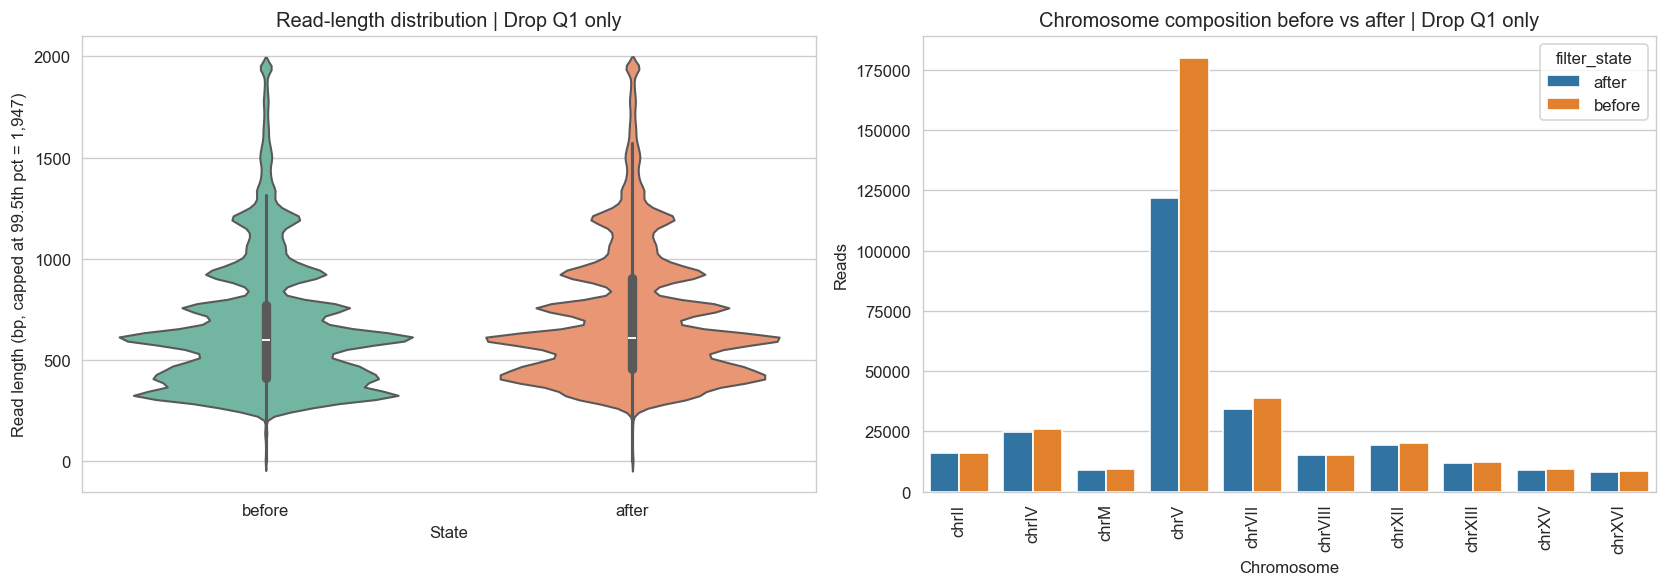

Max read length in data: 133,807 bp
Plot capped at 99.5th percentile: 1,947 bp


In [13]:
dist_df = pd.concat([
    best_alignments.assign(filter_state='before'),
    best_alignments_filtered.assign(filter_state='after')
], ignore_index=True)
dist_df['read_length_bp'] = dist_df['seq'].fillna('').astype(str).str.len()
dist_df = dist_df[dist_df['read_length_bp'] > 0].copy()

plot_cap_bp = float(dist_df['read_length_bp'].quantile(0.995))
dist_df['read_length_plot_bp'] = dist_df['read_length_bp'].clip(upper=plot_cap_bp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(
    data=dist_df,
    x='filter_state',
    y='read_length_plot_bp',
    hue='filter_state',
    legend=False,
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title(f'Read-length distribution | {FILTER_LABEL}')
axes[0].set_xlabel('State')
axes[0].set_ylabel(f'Read length (bp, capped at 99.5th pct = {plot_cap_bp:,.0f})')

chrom_comp = (
    dist_df.groupby(['filter_state', 'chrom'], as_index=False)
    .size()
    .rename(columns={'size': 'reads'})
)
top_chroms = chrom_comp.groupby('chrom')['reads'].sum().sort_values(ascending=False).head(10).index.tolist()
sns.barplot(data=chrom_comp[chrom_comp['chrom'].isin(top_chroms)], x='chrom', y='reads', hue='filter_state', ax=axes[1])
axes[1].set_title(f'Chromosome composition before vs after | {FILTER_LABEL}')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xlabel('Chromosome')
axes[1].set_ylabel('Reads')
plt.tight_layout()
plt.show()

print(f'Max read length in data: {dist_df["read_length_bp"].max():,} bp')
print(f'Plot capped at 99.5th percentile: {plot_cap_bp:,.0f} bp')

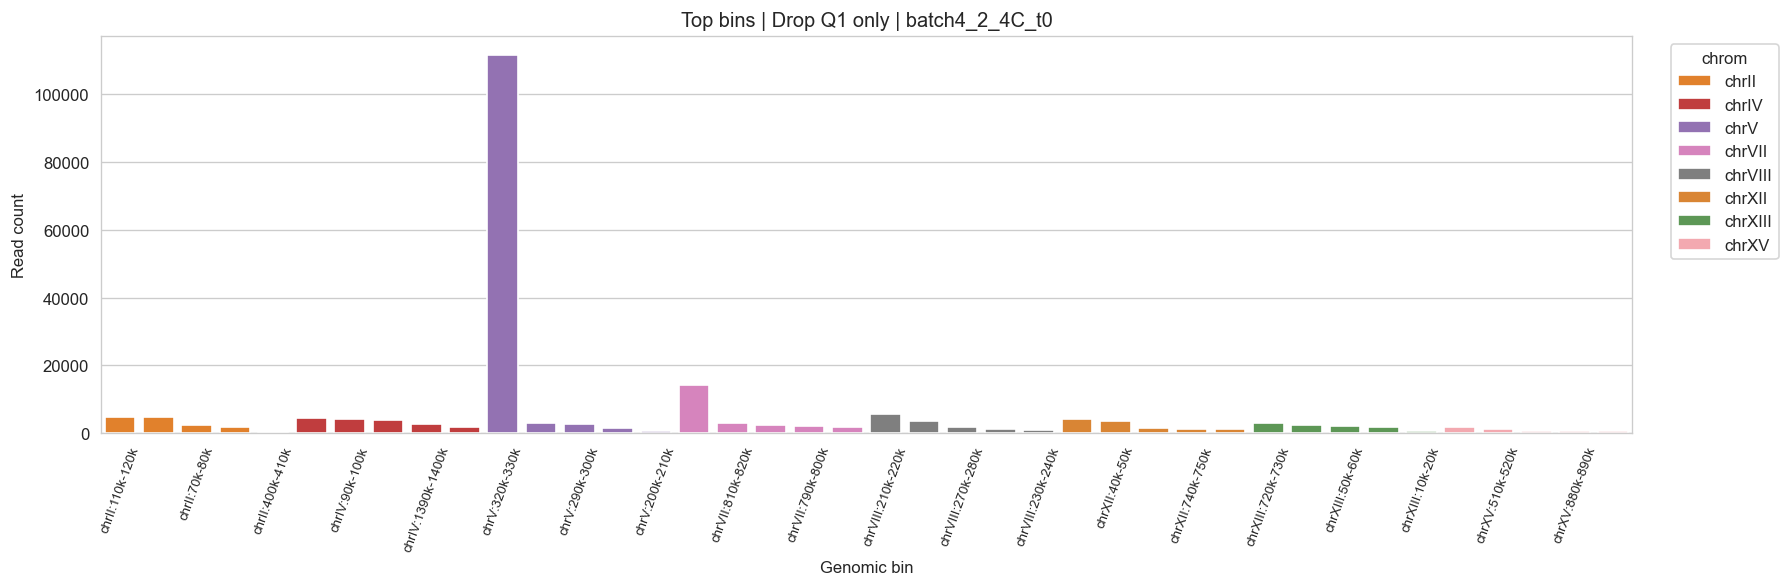

In [14]:
for sample_name, sdf in bin_counts_filtered.groupby('sample'):
    chrom_rank = (
        sdf.groupby('chrom', as_index=False)['count'].sum()
        .sort_values('count', ascending=False)
        .head(CONTACT_PLOT_TOP_CHROMS)
    )
    chosen_chroms = set(chrom_rank['chrom'].tolist())
    candidate = sdf[sdf['chrom'].isin(chosen_chroms)].copy()
    candidate = candidate.sort_values(['chrom', 'count'], ascending=[True, False])
    per_chrom_top = candidate.groupby('chrom', as_index=False).head(CONTACT_PLOT_BINS_PER_CHROM).copy()
    p = per_chrom_top.sort_values('count', ascending=False).head(CONTACT_PLOT_MAX_BARS).copy()
    p['bin_label_short'] = p['bin_id'].map(short_bin_label)
    p['chrom_order'] = p['chrom'].map(lambda x: chrom_order_index.get(x, 10_000))
    p = p.sort_values(['chrom_order', 'count'], ascending=[True, False]).reset_index(drop=True)
    hue_order = [c for c in CHROM_ORDER if c in set(p['chrom'])]
    extra_chroms = sorted([c for c in pd.unique(p['chrom']) if c not in set(hue_order)])
    hue_order.extend(extra_chroms)
    palette_map = {chrom: CHROM_PALETTE.get(chrom, fallback_colors[i % len(fallback_colors)]) for i, chrom in enumerate(hue_order)}
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(data=p, x='bin_label_short', y='count', hue='chrom', order=p['bin_label_short'].tolist(), hue_order=hue_order, dodge=False, palette=palette_map)
    ax.set_title(f'Top bins | {FILTER_LABEL} | {sample_name}')
    ax.set_xlabel('Genomic bin')
    ax.set_ylabel('Read count')
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_rotation(70)
        tick.set_fontsize(8)
        tick.set_visible(i % max(1, len(p) // 16) == 0)
    plt.legend(title='chrom', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

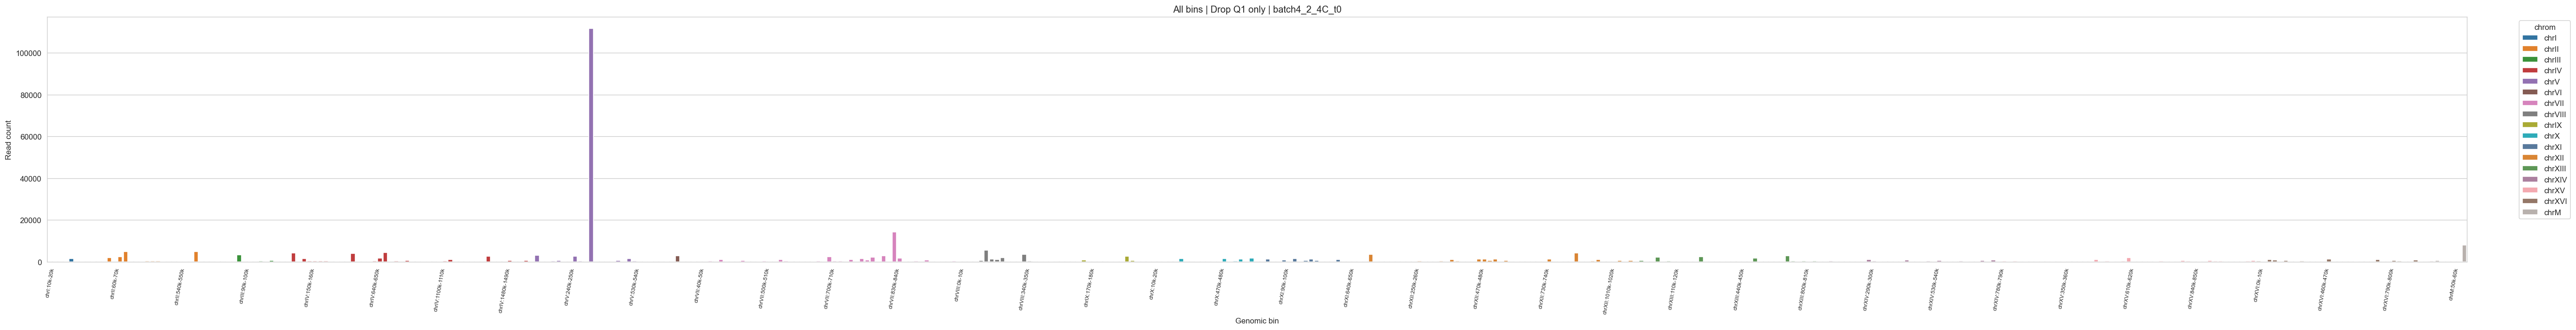

In [15]:
for sample_name, sdf in bin_counts_filtered.groupby('sample'):
    p_all = sdf.copy()
    p_all['chrom_order'] = p_all['chrom'].map(lambda x: chrom_order_index.get(x, 10_000))
    p_all = p_all.sort_values(['chrom_order', 'chrom', 'bin_start'], ascending=[True, True, True]).reset_index(drop=True)
    p_all['bin_label_short'] = p_all['bin_id'].map(short_bin_label)
    hue_order_all = [c for c in CHROM_ORDER if c in set(p_all['chrom'])]
    extra_chroms_all = sorted([c for c in pd.unique(p_all['chrom']) if c not in set(hue_order_all)])
    hue_order_all.extend(extra_chroms_all)
    palette_map_all = {chrom: CHROM_PALETTE.get(chrom, fallback_colors[i % len(fallback_colors)]) for i, chrom in enumerate(hue_order_all)}
    fig_w = max(18, min(46, 0.16 * len(p_all)))
    plt.figure(figsize=(fig_w, 6))
    ax_all = sns.barplot(data=p_all, x='bin_label_short', y='count', hue='chrom', order=p_all['bin_label_short'].tolist(), hue_order=hue_order_all, dodge=False, palette=palette_map_all)
    ax_all.set_title(f'All bins | {FILTER_LABEL} | {sample_name}')
    ax_all.set_xlabel('Genomic bin')
    ax_all.set_ylabel('Read count')
    for i, tick in enumerate(ax_all.get_xticklabels()):
        tick.set_rotation(80)
        tick.set_fontsize(7)
        tick.set_visible(i % max(1, len(p_all) // 35) == 0)
    plt.legend(title='chrom', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

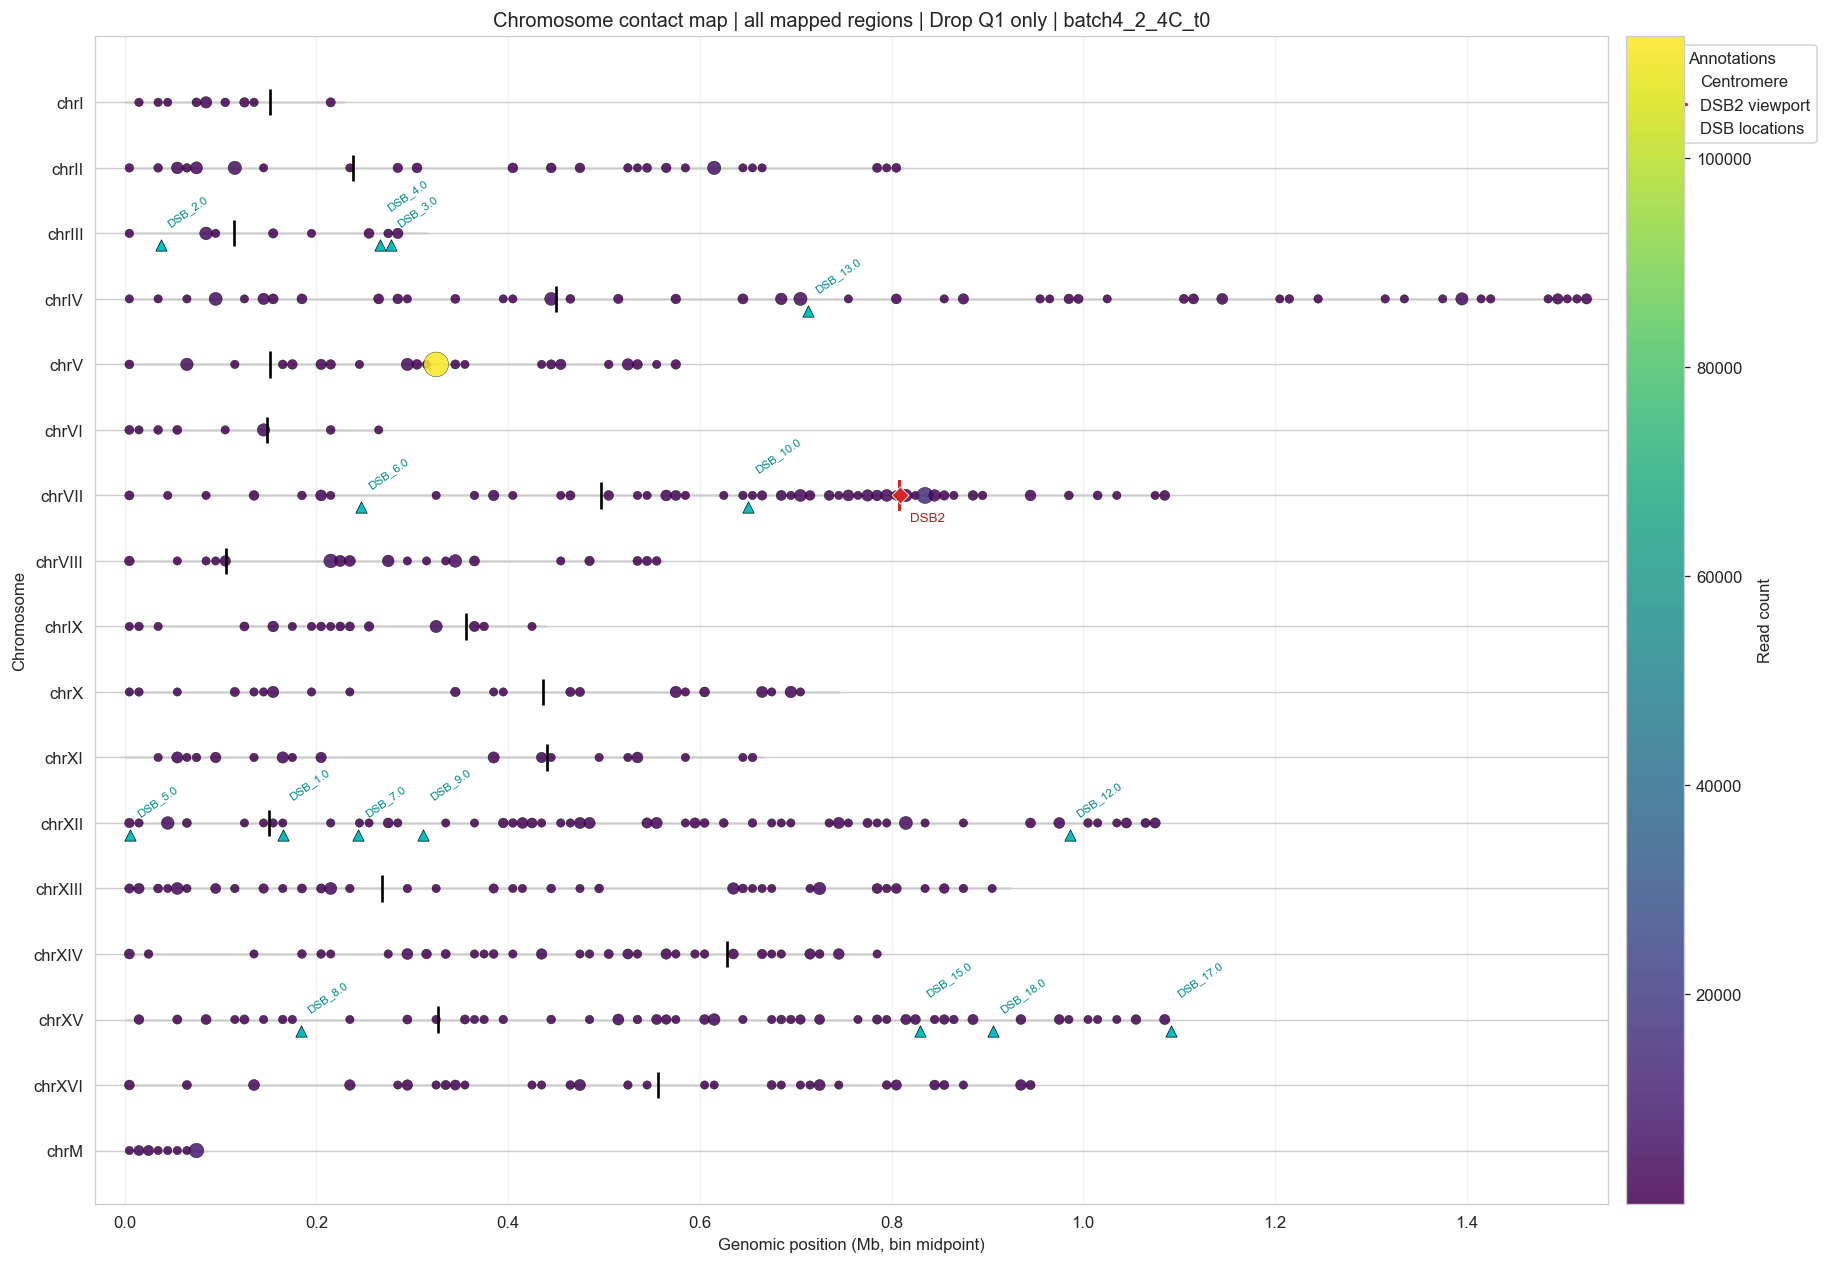

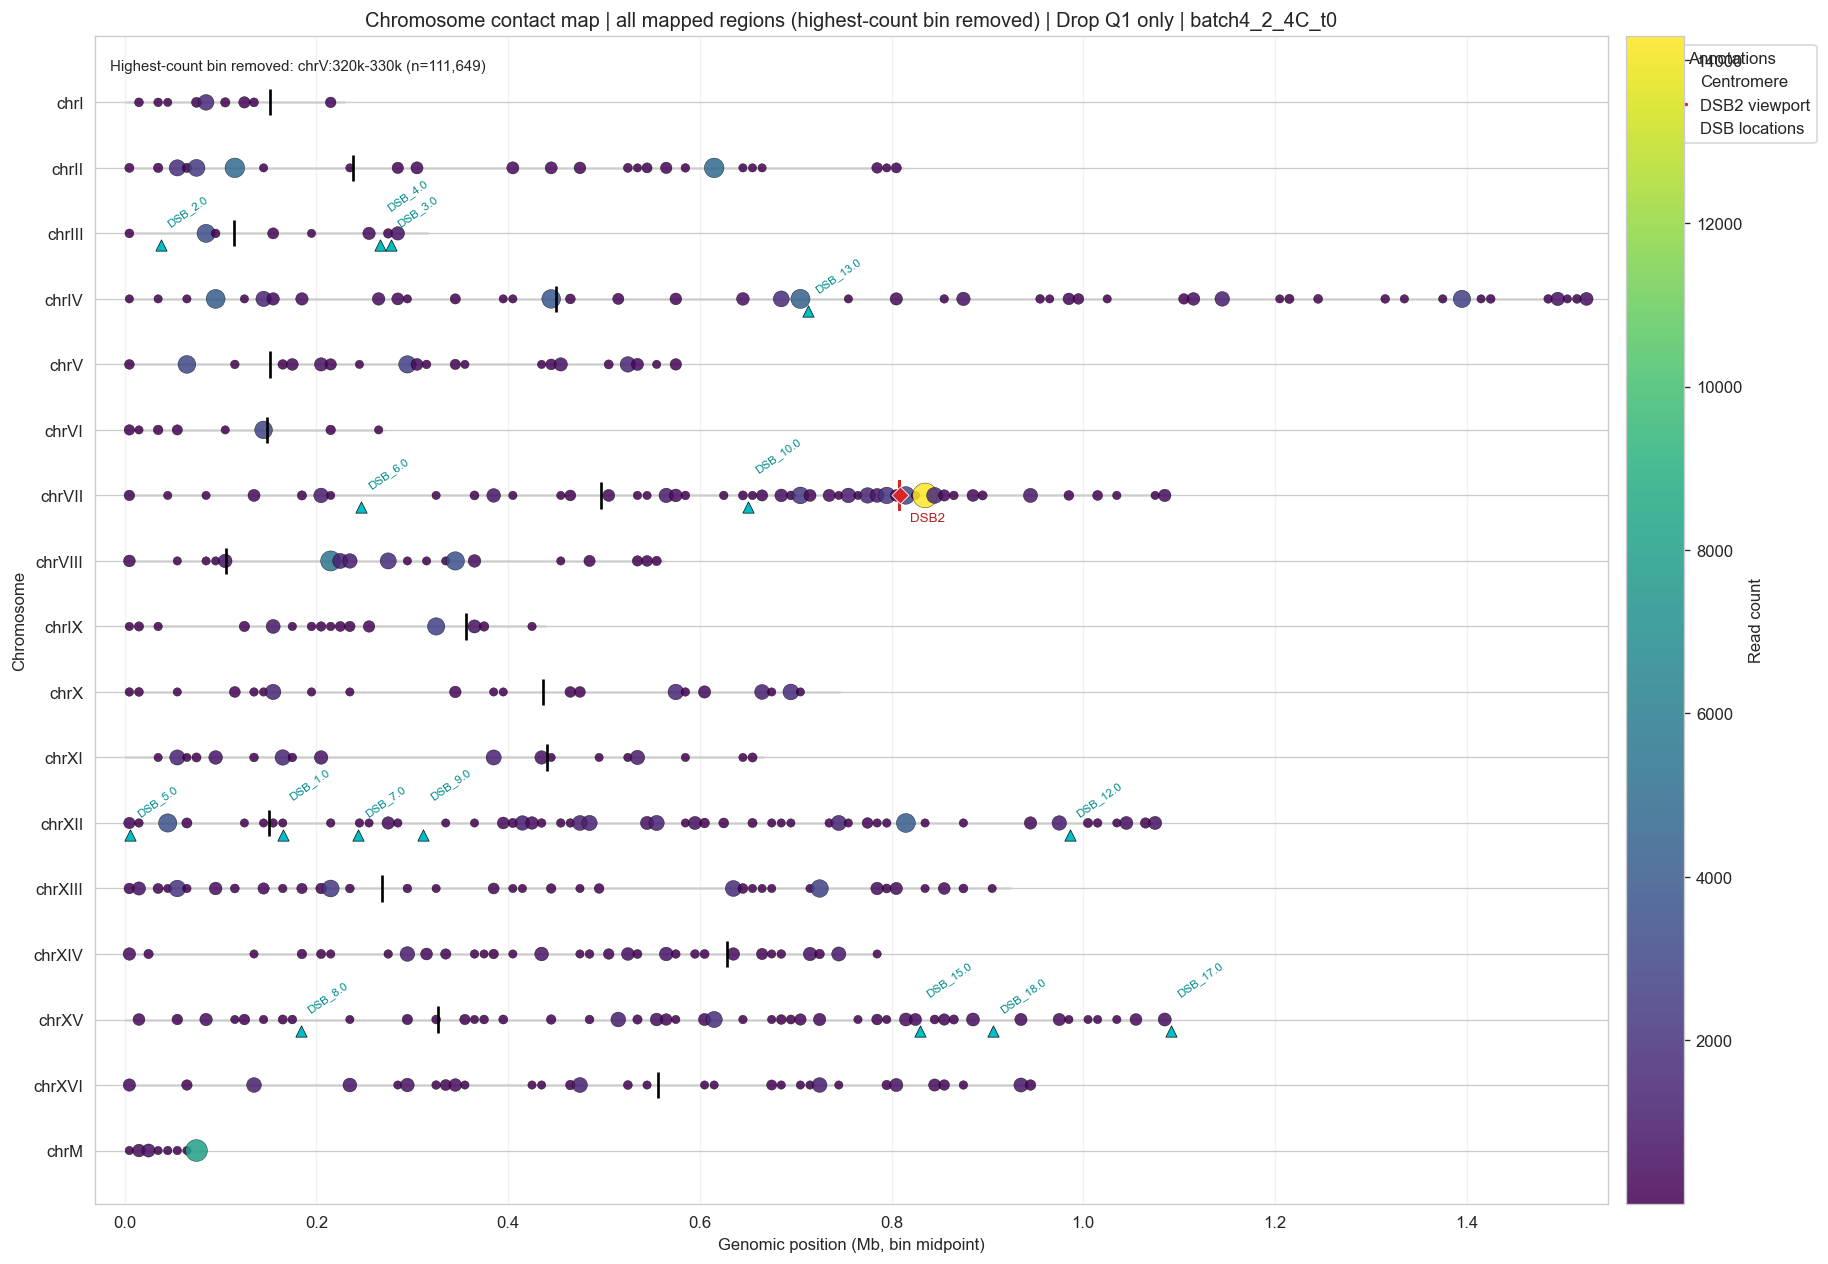

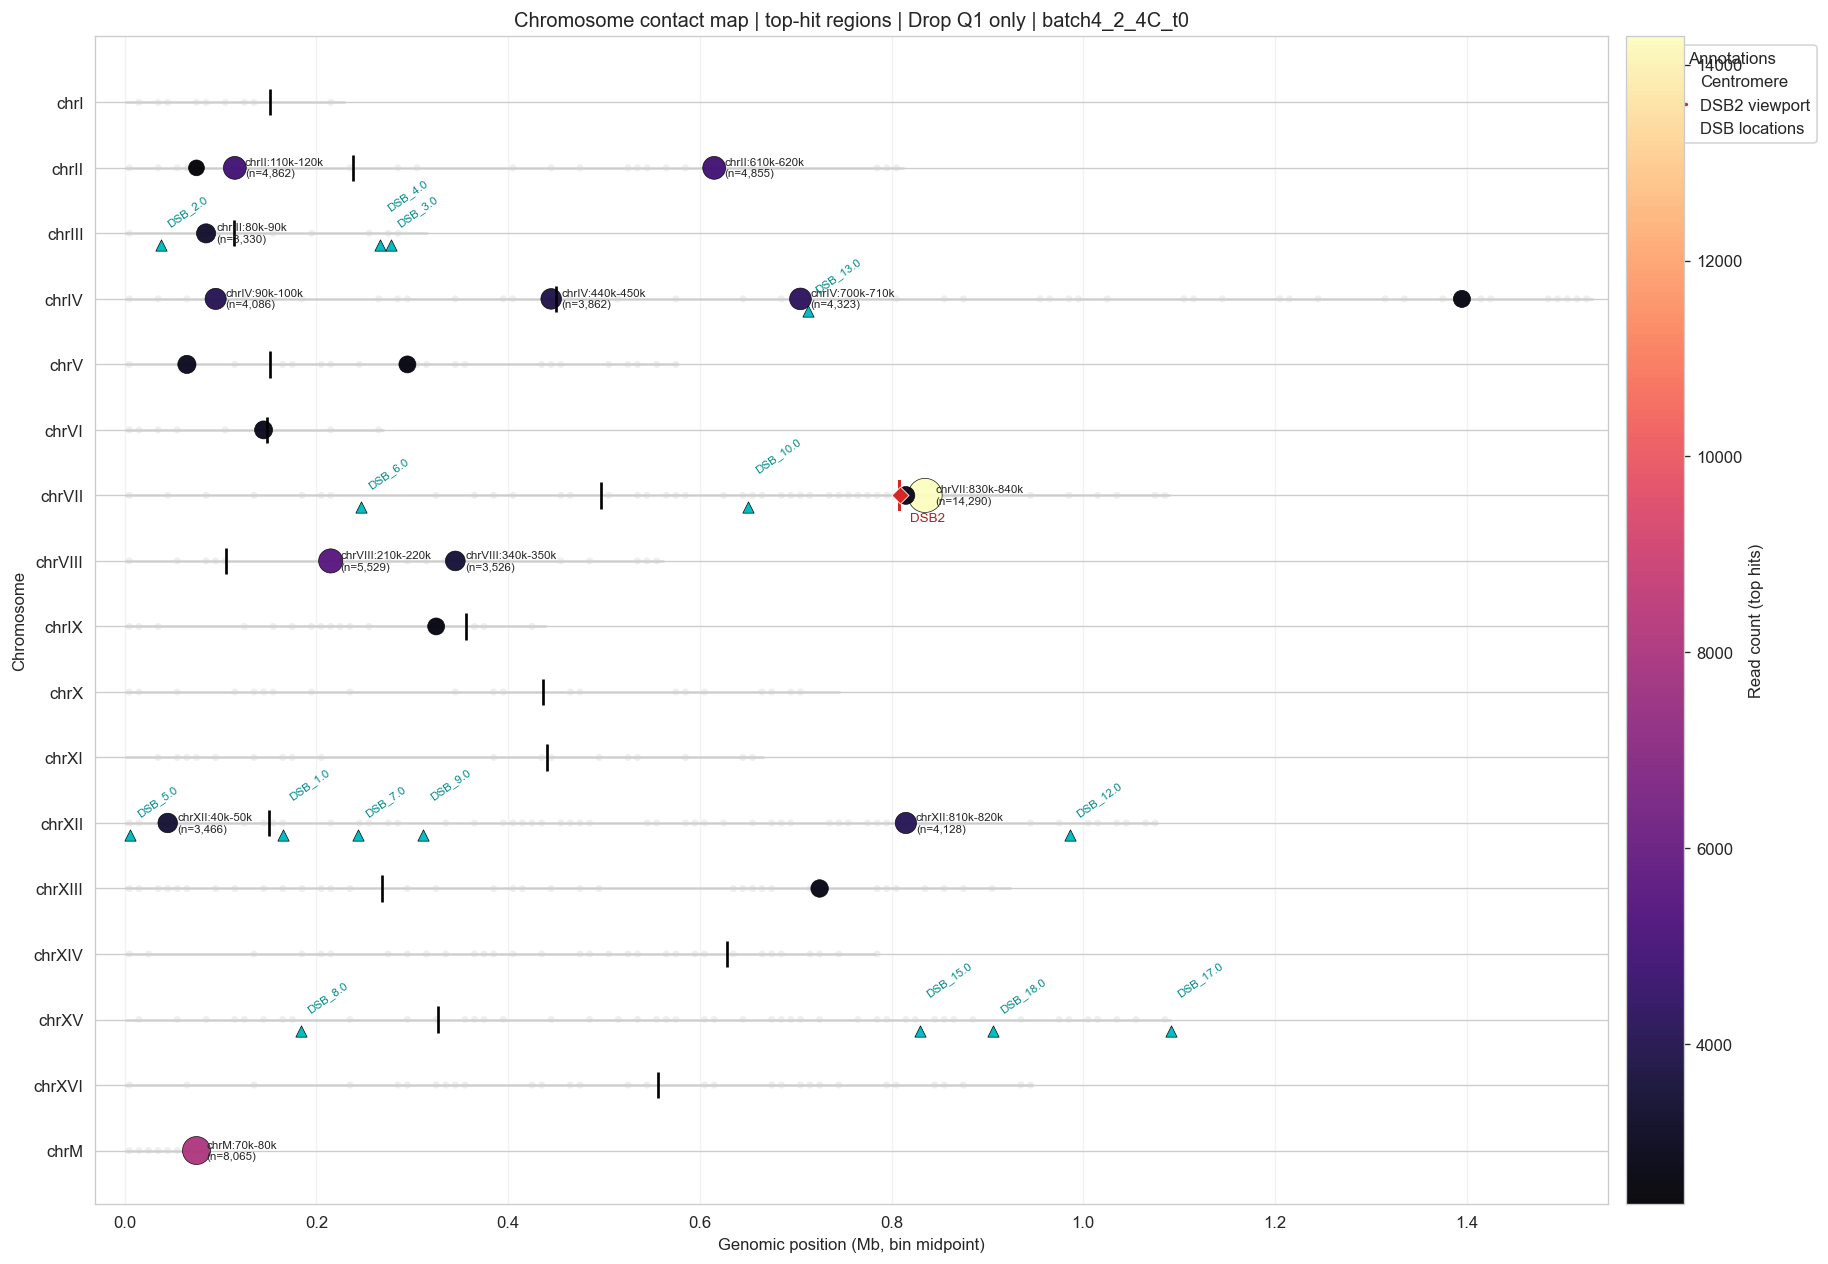

In [18]:
from matplotlib.lines import Line2D


def _scaled_marker_sizes(values, min_size=30, max_size=260):
    values = pd.Series(values, dtype=float)
    if values.empty:
        return np.array([])
    rooted = np.sqrt(values)
    vmin, vmax = rooted.min(), rooted.max()
    if vmax == vmin:
        return np.full(len(values), (min_size + max_size) / 2.0)
    return min_size + (rooted - vmin) * (max_size - min_size) / (vmax - vmin)


DSB2_VIEWPORT = {
    'label': 'DSB2',
    'chrom': 'chrVII',
    'start': 808_154,
    'end': 808_854,
}

YEAST_CHR_LENGTHS = {
    'chrI': 230_218, 'chrII': 813_184, 'chrIII': 316_620, 'chrIV': 1_531_933,
    'chrV': 576_874, 'chrVI': 270_161, 'chrVII': 1_090_940, 'chrVIII': 562_643,
    'chrIX': 439_888, 'chrX': 745_751, 'chrXI': 666_816, 'chrXII': 1_078_177,
    'chrXIII': 924_431, 'chrXIV': 784_333, 'chrXV': 1_091_291, 'chrXVI': 948_066,
    'chrM': 85_779,
}

YEAST_CENTROMERES = {
    'chrI': 151_583, 'chrII': 238_323, 'chrIII': 114_385, 'chrIV': 449_711,
    'chrV': 151_465, 'chrVI': 148_510, 'chrVII': 497_038, 'chrVIII': 105_703,
    'chrIX': 355_629, 'chrX': 436_425, 'chrXI': 440_246, 'chrXII': 150_947,
    'chrXIII': 268_031, 'chrXIV': 628_758, 'chrXV': 326_584, 'chrXVI': 556_070,
}

PROJECT_DSB_PATH = Path.cwd() / 'Outputs' / '4C_python' / 'dsb_locations_saccer3_approx.csv'
EXTERNAL_DSB_CSV_PATH = Path(r'H:\My Documents\Insertion Primers for Locations of DSBs.csv')


def _roman_to_chr(roman):
    roman = str(roman).strip().upper()
    valid = {
        'I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII',
        'IX', 'X', 'XI', 'XII', 'XIII', 'XIV', 'XV', 'XVI', 'M'
    }
    if roman in valid:
        return 'chrM' if roman == 'M' else f'chr{roman}'
    return None


def _extract_chr_from_primer_name(x):
    s = str(x)
    m = re.match(r'\s*([IVX]+|M)_', s, flags=re.IGNORECASE)
    if not m:
        return None
    return _roman_to_chr(m.group(1))


def _extract_dsb_from_csv(csv_path):
    if not csv_path.exists():
        return pd.DataFrame(columns=['dsb_name', 'chrom', 'position'])

    d = pd.read_csv(csv_path)
    if d.empty:
        return pd.DataFrame(columns=['dsb_name', 'chrom', 'position'])

    cols = {c.lower().strip(): c for c in d.columns}
    col_loc = cols.get('location')
    col_primer = cols.get('primer name')
    col_c1 = cols.get('chromosome coordinate')
    col_c2 = cols.get('chromosome coordinate.1')

    if col_primer is None:
        for c in d.columns:
            lc = c.lower()
            if 'primer' in lc and 'name' in lc:
                col_primer = c
                break

    if col_c1 is None or col_c2 is None:
        num_cols = [c for c in d.columns if pd.api.types.is_numeric_dtype(d[c])]
        if len(num_cols) >= 2:
            col_c1, col_c2 = num_cols[:2]

    dd = d.copy()
    dd['chrom'] = dd[col_primer].map(_extract_chr_from_primer_name) if col_primer is not None else None
    dd['coord_start'] = pd.to_numeric(dd[col_c1], errors='coerce') if col_c1 is not None else np.nan
    dd['coord_end'] = pd.to_numeric(dd[col_c2], errors='coerce') if col_c2 is not None else np.nan
    dd['location_id'] = dd[col_loc].astype(str).str.strip() if col_loc is not None else np.arange(1, len(dd) + 1).astype(str)

    agg = (
        dd.groupby('location_id', dropna=False)
          .agg(
              dsb_name=('location_id', lambda x: f'DSB_{x.iloc[0]}'),
              chrom=('chrom', lambda x: next((v for v in x if isinstance(v, str) and v.startswith('chr')), None)),
              start=('coord_start', 'min'),
              end=('coord_end', 'max')
          )
          .reset_index(drop=True)
    )
    agg['position'] = np.floor((agg['start'] + agg['end']) / 2.0)
    return agg[['dsb_name', 'chrom', 'position']]


def _load_dsb_locations():
    dsb_df = pd.DataFrame(columns=['dsb_name', 'chrom', 'position'])
    if PROJECT_DSB_PATH.exists():
        dsb_df = pd.read_csv(PROJECT_DSB_PATH)
    elif EXTERNAL_DSB_CSV_PATH.exists():
        dsb_df = _extract_dsb_from_csv(EXTERNAL_DSB_CSV_PATH)

    if dsb_df.empty:
        return dsb_df

    keep_cols = [c for c in ['dsb_name', 'chrom', 'position'] if c in dsb_df.columns]
    dsb_df = dsb_df[keep_cols].copy()
    if 'dsb_name' not in dsb_df.columns:
        dsb_df['dsb_name'] = 'DSB'
    dsb_df['chrom'] = dsb_df['chrom'].astype(str)
    dsb_df['position'] = pd.to_numeric(dsb_df['position'], errors='coerce')
    dsb_df = dsb_df[dsb_df['chrom'].notna() & dsb_df['position'].notna()].copy()
    dsb_df = dsb_df[dsb_df['chrom'].str.startswith('chr')].reset_index(drop=True)
    return dsb_df


def _draw_reference_annotations(ax, chrom, y, chr_len_mb, dsb_locs):
    cen = YEAST_CENTROMERES.get(chrom)
    if cen is not None:
        cen_mb = cen / 1_000_000.0
        ax.vlines(cen_mb, y - 0.20, y + 0.20, color='black', linewidth=1.6, zorder=4)

    if chrom == DSB2_VIEWPORT['chrom']:
        dsb2_start_mb = DSB2_VIEWPORT['start'] / 1_000_000.0
        dsb2_end_mb = DSB2_VIEWPORT['end'] / 1_000_000.0
        dsb2_mid_mb = (DSB2_VIEWPORT['start'] + DSB2_VIEWPORT['end']) / 2 / 1_000_000.0
        ax.hlines(y, dsb2_start_mb, dsb2_end_mb, color='#d62728', linewidth=5, zorder=5)
        ax.vlines([dsb2_start_mb, dsb2_end_mb], y - 0.24, y + 0.24, color='#d62728', linewidth=1.2, zorder=6)
        ax.scatter([dsb2_mid_mb], [y], s=52, color='#d62728', marker='D', edgecolor='white', linewidth=0.5, zorder=7)
        ax.annotate(
            DSB2_VIEWPORT['label'],
            xy=(dsb2_mid_mb, y),
            xytext=(6, -10),
            textcoords='offset points',
            fontsize=8,
            color='#b22222',
            ha='left',
            va='top',
            zorder=8,
        )

    if dsb_locs.empty:
        return

    dsub = dsb_locs[dsb_locs['chrom'] == chrom].copy()
    if dsub.empty:
        return

    dsub = dsub.sort_values('position').reset_index(drop=True)
    dsub['position_mb'] = dsub['position'] / 1_000_000.0
    dsub['position_mb'] = dsub['position_mb'].clip(lower=0, upper=chr_len_mb)
    ax.scatter(
        dsub['position_mb'],
        np.repeat(y + 0.18, len(dsub)),
        s=46,
        color='#00BFC4',
        marker='^',
        edgecolor='black',
        linewidth=0.4,
        zorder=6,
    )
    for i, (_, rr) in enumerate(dsub.iterrows()):
        offset_y = 10 if i % 2 == 0 else 20
        ax.annotate(
            str(rr['dsb_name']),
            xy=(rr['position_mb'], y + 0.18),
            xytext=(3, offset_y),
            textcoords='offset points',
            fontsize=7,
            rotation=35,
            color='#008B8B',
            ha='left',
            va='bottom',
            zorder=7,
        )


def _get_chrom_extent_mb(chrom, sdf_in):
    known_len_mb = YEAST_CHR_LENGTHS.get(chrom, np.nan)
    if pd.notna(known_len_mb):
        return float(known_len_mb) / 1_000_000.0
    observed_end = sdf_in.loc[sdf_in['chrom'] == chrom, 'bin_end'].max()
    if pd.notna(observed_end):
        return float(observed_end) / 1_000_000.0
    return 0.0


def _format_gradient_map(ax, chroms_present, xmax_mb):
    ax.set_yticks(range(len(chroms_present)))
    ax.set_yticklabels(chroms_present)
    ax.invert_yaxis()
    ax.set_xlabel('Genomic position (Mb, bin midpoint)')
    ax.set_ylabel('Chromosome')
    ax.grid(axis='x', alpha=0.25)
    ax.set_xlim(-0.02 * xmax_mb, 1.01 * xmax_mb)


def _build_plot_df(sdf_in, chrom_to_y):
    plot_df = sdf_in.copy()
    plot_df['chrom_y'] = plot_df['chrom'].map(chrom_to_y)
    plot_df['bin_mid_mb'] = (plot_df['bin_start'] + plot_df['bin_end']) / 2 / 1_000_000.0
    plot_df['region_label'] = plot_df['bin_id'].map(short_bin_label)
    return plot_df


def _draw_baselines(ax, chrom_to_y, chrom_extent_mb, dsb_locations_map):
    for chrom, y in chrom_to_y.items():
        ax.hlines(y=y, xmin=0, xmax=chrom_extent_mb.get(chrom, 0.0), color='gainsboro', linewidth=1.6, zorder=0)
        _draw_reference_annotations(ax, chrom, y, chrom_extent_mb.get(chrom, 0.0), dsb_locations_map)


def _plot_all_regions_map(plot_df, chroms_present, chrom_to_y, chrom_extent_mb, dsb_locations_map, sample_name, title_suffix, removed_note=None):
    xmax_mb = max(chrom_extent_mb.values()) if chrom_extent_mb else 0.0
    fig, ax = plt.subplots(figsize=(16, max(5, 0.52 * len(chroms_present) + 1.8)))
    _draw_baselines(ax, chrom_to_y, chrom_extent_mb, dsb_locations_map)

    scatter_all = ax.scatter(
        plot_df['bin_mid_mb'],
        plot_df['chrom_y'],
        s=_scaled_marker_sizes(plot_df['count'], min_size=25, max_size=220),
        c=plot_df['count'],
        cmap='viridis',
        alpha=0.85,
        edgecolor='black',
        linewidth=0.25,
        zorder=3,
    )
    _format_gradient_map(ax, chroms_present, xmax_mb)
    ax.set_title(f'Chromosome contact map | {title_suffix} | {FILTER_LABEL} | {sample_name}')
    if removed_note is not None:
        ax.text(0.01, 0.98, removed_note, transform=ax.transAxes, ha='left', va='top', fontsize=9)
    ax.legend(handles=reference_legend, loc='upper left', bbox_to_anchor=(1.02, 1.0), title='Annotations')
    cbar = fig.colorbar(scatter_all, ax=ax, pad=0.01)
    cbar.set_label('Read count')
    plt.tight_layout()
    plt.show()


def _plot_top_hits_map(plot_df, top_hits, chroms_present, chrom_to_y, chrom_extent_mb, dsb_locations_map, sample_name):
    xmax_mb = max(chrom_extent_mb.values()) if chrom_extent_mb else 0.0
    fig, ax = plt.subplots(figsize=(16, max(5, 0.52 * len(chroms_present) + 1.8)))
    _draw_baselines(ax, chrom_to_y, chrom_extent_mb, dsb_locations_map)

    ax.scatter(
        plot_df['bin_mid_mb'],
        plot_df['chrom_y'],
        s=18,
        c='lightgray',
        alpha=0.35,
        edgecolor='none',
        zorder=1,
    )
    scatter_top = ax.scatter(
        top_hits['bin_mid_mb'],
        top_hits['chrom_y'],
        s=_scaled_marker_sizes(top_hits['count'], min_size=90, max_size=420),
        c=top_hits['count'],
        cmap='magma',
        alpha=0.95,
        edgecolor='black',
        linewidth=0.4,
        zorder=3,
    )

    annotate_n = min(12, len(top_hits))
    for _, row in top_hits.head(annotate_n).iterrows():
        ax.annotate(
            f"{row['region_label']}\n(n={int(row['count']):,})",
            xy=(row['bin_mid_mb'], row['chrom_y']),
            xytext=(6, 0),
            textcoords='offset points',
            fontsize=7,
            va='center',
            ha='left',
            zorder=4,
        )

    _format_gradient_map(ax, chroms_present, xmax_mb)
    ax.set_title(f'Chromosome contact map | top-hit regions | {FILTER_LABEL} | {sample_name}')
    ax.legend(handles=reference_legend, loc='upper left', bbox_to_anchor=(1.02, 1.0), title='Annotations')
    cbar = fig.colorbar(scatter_top, ax=ax, pad=0.01)
    cbar.set_label('Read count (top hits)')
    plt.tight_layout()
    plt.show()


reference_legend = [
    Line2D([0], [0], color='black', marker='|', linestyle='None', markersize=14, markeredgewidth=1.6, label='Centromere'),
    Line2D([0], [0], color='#d62728', marker='D', linestyle='-', linewidth=2, markersize=6, label='DSB2 viewport'),
    Line2D([0], [0], color='#00BFC4', marker='^', linestyle='None', markeredgecolor='black', markersize=7, label='DSB locations'),
]

dsb_locations_map = _load_dsb_locations()

for sample_name, sdf in bin_counts_filtered.groupby('sample'):
    chroms_present = [c for c in CHROM_ORDER if c in set(sdf['chrom'])]
    extra_chroms = sorted([c for c in pd.unique(sdf['chrom']) if c not in set(chroms_present)])
    chroms_present.extend(extra_chroms)
    chrom_to_y = {chrom: idx for idx, chrom in enumerate(chroms_present)}
    chrom_extent_mb = {chrom: _get_chrom_extent_mb(chrom, sdf) for chrom in chroms_present}

    plot_df = _build_plot_df(sdf, chrom_to_y)
    _plot_all_regions_map(
        plot_df,
        chroms_present,
        chrom_to_y,
        chrom_extent_mb,
        dsb_locations_map,
        sample_name,
        title_suffix='all mapped regions',
    )

    if len(plot_df) > 1:
        highest_idx = plot_df['count'].idxmax()
        removed_row = plot_df.loc[highest_idx]
        plot_df_without_max = plot_df.drop(index=highest_idx).copy()
        removed_note = f"Highest-count bin removed: {removed_row['region_label']} (n={int(removed_row['count']):,})"
        _plot_all_regions_map(
            plot_df_without_max,
            chroms_present,
            chrom_to_y,
            chrom_extent_mb,
            dsb_locations_map,
            sample_name,
            title_suffix='all mapped regions (highest-count bin removed)',
            removed_note=removed_note,
        )
    else:
        plot_df_without_max = plot_df.copy()

    top_n = min(20, len(plot_df_without_max))
    top_hits = plot_df_without_max.sort_values('count', ascending=False).head(top_n).copy()
    _plot_top_hits_map(
        plot_df_without_max,
        top_hits,
        chroms_present,
        chrom_to_y,
        chrom_extent_mb,
        dsb_locations_map,
        sample_name,
    )

## Final interpretation alignment with pooled-strain design

Apply the same design rules used across project reports:

- DSB1 varies by strain across the pooled panel.
- DSB2 is batch-specific (4→Chr VII, 6→Chr IV, 8→Chr XV).
- Interpret endpoint differences by biological state and anchor context, not pooled anchor assumptions.

### Guardrails

1. Keep trans/contact interpretation batch-anchored.
2. Avoid global cross-batch DSB2 conclusions without explicit modeling.
3. Treat pooled plots as descriptive summaries only.

### Reporting statement

All biological conclusions from this notebook should remain **batch-specific DSB2-anchor interpretations**.